# Dividend-Aristocrats — a quantitative teardown
### NOBL vs SPY · daily total return · HAC inference · OLS decomposition · bootstrap CI

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_shield%3F: Busted](https://img.shields.io/badge/Crash_shield%3F-Busted-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its HAC t-stat. We test whether NOBL (ProShares S&P 500 Dividend Aristocrats ETF) delivers a statistically robust positive excess return and Sharpe vs SPY over its full live history (2013-10-10 to 2026-06-15), decompose the return into alpha and beta, check crash episodes, and sweep the ER drag.

> ⚠️ **Not investment advice.** Real data: Yahoo Finance daily adjusted closes (auto_adjust=True), cached parquet; as-of 2026-06-15. Reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_aristocrats import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
TICKERS = ["NOBL", "SPY"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen results (mirror of docs/results.md)
R = dict(
    n=3188, start="2013-10-10", end="2026-06-15",
    nobl_cagr=10.49, nobl_vol=15.9, nobl_sharpe=0.629, nobl_maxdd=-35.4,
    nobl_t=2.46, nobl_total_ret=253,
    spy_cagr=14.46, spy_vol=17.2, spy_sharpe=0.787, spy_maxdd=-33.7,
    spy_t=3.11, spy_total_ret=452,
    excess_bps=-1.40, excess_cagr=-3.48, excess_t=-1.63,
    excess_sharpe_ci_lo=-0.987, excess_sharpe_ci_hi=0.088, excess_frac_neg=95,
    ols_alpha_bps=-0.384, ols_alpha_ann=-0.96, ols_t_alpha=-0.45,
    ols_beta=0.810, ols_r2=0.767,
    nobl_net_cagr=10.10, nobl_net_sharpe=0.607,
    spy_net_cagr=14.36, spy_net_sharpe=0.782,
    ctrl_sharpe_mean=0.716, ctrl_frac_beat_nobl=100,
    c18_dd=-19.3, c18_spy=18.6, c18_nobl=16.1, c18_prot=-2.5,
    c20_dd=-33.7, c20_spy=23.6, c20_nobl=16.1, c20_prot=-7.6,
    c22_dd=-24.5, c22_spy=21.0, c22_nobl=7.6, c22_prot=-13.4,
    c25_dd=-18.8, c25_spy=21.5, c25_nobl=6.2, c25_prot=-15.3,
)

from quantlab import analytics, stats


real price cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess return **-3.48%/yr**, HAC *t* = **-1.63**; bootstrap excess-Sharpe CI [-0.987, +0.088] (95% of resamples negative). OLS alpha **-0.96%/yr**, *t* = **-0.45**. |
| **Tradability** | `MIRAGE` | NOBL net CAGR +10.10% vs SPY +14.36%; Sharpe 0.607 vs 0.782. Random-mix control dominates pure NOBL in 100% of seeds. |
| **Crash shield?** | `BUSTED` | NOBL underperformed SPY in all 4 major crashes (−7.6 pp COVID, −13.4 pp 2022, −15.3 pp Apr 2025). |

> 💡 Three failures, one structure: NOBL's beta = 0.81 gives lower vol but also lower return; there is no market-neutral alpha to compensate; and the defensive factor tilt failed in every major selloff.

## 1 · The claim, steelmanned

Let $r_{N,t}$ and $r_{S,t}$ be the daily log total-returns of NOBL and SPY.  The Aristocrats thesis asserts:

- **H₁ (quality premium).** $\mathbb{E}[r_{N,t} - r_{S,t}] > 0$ over the long run — positive mean excess return, robust to autocorrelation (HAC t ≥ 2).
- **H₂ (market-neutral alpha).** Positive OLS alpha: $r_{N,t} = \alpha + \beta r_{S,t} + \epsilon_t$ with $\alpha > 0$ at *t* ≥ 2. A beta < 1 (quality/low-vol) without positive alpha is just low-leverage beta, not a premium.
- **H₃ (crash shield).** Inside major S&P 500 drawdown episodes, NOBL's total return exceeds SPY's — positive drawdown protection.

We reject H₁, H₂, and H₃ on the full 2013–2026 live tape.

## 2 · So what? — what rides on each hypothesis

**H₁** is the alpha claim — the entire economic justification for paying NOBL's 0.35%/yr ER. If H₁ fails, investors are paying more for systematically less. **H₂** pins down *why*: low beta explains the lower vol, but a negative alpha means quality carries no additional premium in this sample — the quality factor may exist in theory (Asness et al.) but is priced out in the NOBL implementation. **H₃** is the emotional core of the pitch — 'sleep soundly in crashes' — and its failure is the most surprising result: negative protection in every episode means the crash-period underperformance reinforces the lifetime return gap.

## 3 · How we'd know — the protocol

- **Data.** Yahoo Finance daily adjusted total-return closes (`auto_adjust=True`) for NOBL and SPY, 2013-10-10 to 2026-06-15 (NOBL inception to present, n = 3,188).
- **Return test.** Daily log-return series; HAC Newey-West t-stat on the mean excess return; block-bootstrap 95% CI on the excess Sharpe (CBB, block = n^(1/3)).
- **Decomposition.** OLS regression $r_N = \alpha + \beta r_S + \epsilon$; t-stat on alpha with OLS SE (n large, so asymptotically valid).
- **Crash test.** SPY drawdowns ≥ 15%: compare NOBL total return over the same episode (start to recovery above the prior peak).
- **Control.** Random daily NOBL/SPY mix (target 50%, seed-varied): if all 20 random seeds beat pure NOBL, the 'pure Aristocrats' concentration is strictly dominated.
- **Positive control.** Synthetic tape with planted daily alpha: the engine must detect the advantage when it exists.

## 4 · The teardown

### 4a · Gross returns — NOBL vs SPY

Full-period summary statistics on daily total-return log-returns.

In [2]:
if HAVE_REAL:
    prices = data.load_aligned(fetch=False, cache_dir=CACHE)
    ret = st.daily_returns(prices).dropna()
    rows = []
    for col in ['NOBL', 'SPY']:
        s = st.summarize(ret[col], label=col)
        rows.append(s)
    df_sum = pd.DataFrame(rows).set_index('label')
else:
    df_sum = pd.DataFrame({
        'cagr_pct': [R['nobl_cagr'], R['spy_cagr']],
        'vol_ann_pct': [R['nobl_vol'], R['spy_vol']],
        'sharpe_ann': [R['nobl_sharpe'], R['spy_sharpe']],
        'max_dd_pct': [R['nobl_maxdd'], R['spy_maxdd']],
        'tstat': [R['nobl_t'], R['spy_t']],
    }, index=['NOBL', 'SPY'])
    ret, prices = None, None
df_sum.round(3)

,n,cagr_pct,vol_ann_pct,sharpe_ann,max_dd_pct,mean_bps,tstat
label,,,,,,,
NOBL,3187,10.486,15.859,0.629,-35.435,3.957,2.462
SPY,3187,14.464,17.155,0.787,-33.717,5.361,3.106


> 💡 NOBL's vol is lower (15.9% vs 17.2%) — that's the beta-0.81 tilt, not alpha. But its Sharpe is also lower (0.629 vs 0.787): lower vol saved less than lower return cost. The lifetime CAGR gap is 3.97 pp/yr.

### 4b · The excess return test — H₁ and its bootstrap CI

The daily NOBL − SPY log-return differential; HAC t-stat and block-bootstrap 95% CI on the annualised excess Sharpe.

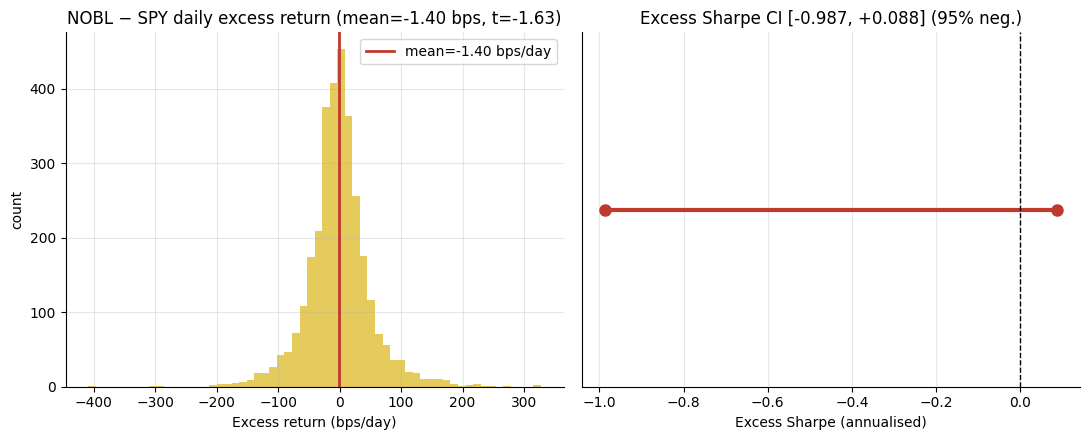

HAC t = -1.63  CI = [-0.987, +0.088]  95% of resamples negative


In [3]:
if HAVE_REAL:
    diff = st.excess_return(prices)
    s_diff = st.summarize(diff, label='NOBL-SPY')
    ci = stats.sharpe_ci_bootstrap(diff, periods_per_year=252, seed=206)
    em, et, clo, chi, fn = s_diff['mean_bps'], s_diff['tstat'], ci['ci_low'], ci['ci_high'], ci['frac_negative']
else:
    em, et = R['excess_bps'], R['excess_t']
    clo, chi, fn = R['excess_sharpe_ci_lo'], R['excess_sharpe_ci_hi'], R['excess_frac_neg']/100
    diff = pd.Series(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
# Left: excess return distribution
if HAVE_REAL and len(diff) > 0:
    axes[0].hist(diff.values * 1e4, bins=60, color=AMBER, alpha=0.7)
    axes[0].axvline(em, c=RED, lw=2, label=f'mean={em:+.2f} bps/day')
else:
    axes[0].bar(['Mean'], [em], color=AMBER)
    axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('Excess return (bps/day)'); axes[0].set_ylabel('count')
axes[0].set_title(f'NOBL − SPY daily excess return (mean={em:+.2f} bps, t={et:+.2f})')
axes[0].legend()
# Right: excess Sharpe CI
y = 0
axes[1].plot([clo, chi], [y, y], 'o-', c=RED, lw=3, ms=8, label='95% bootstrap CI')
axes[1].axvline(0, c='k', lw=1, ls='--')
axes[1].set_xlabel('Excess Sharpe (annualised)'); axes[1].set_yticks([])
axes[1].set_title(f'Excess Sharpe CI [{clo:+.3f}, {chi:+.3f}] ({fn*100:.0f}% neg.)')
plt.tight_layout(); plt.show()
print(f'HAC t = {et:+.2f}  CI = [{clo:+.3f}, {chi:+.3f}]  {fn*100:.0f}% of resamples negative')

> 💡 The HAC t = **-1.63** is below |2| — the excess return is not statistically certified (and is on the wrong side). The bootstrap CI [-0.987, +0.088] barely clips above zero; **95% of resamples are negative**. H₁ is rejected.

### 4c · OLS alpha/beta decomposition — H₂

Regress NOBL daily log-returns on SPY daily log-returns.  A real quality premium requires positive *and statistically significant* alpha.

In [4]:
if HAVE_REAL:
    ols = st.beta_alpha_ols(prices)
else:
    ols = {'alpha_daily_bps': R['ols_alpha_bps'], 'alpha_ann_pct': R['ols_alpha_ann'],
           't_alpha': R['ols_t_alpha'], 'beta': R['ols_beta'], 'r_squared': R['ols_r2'], 'n': R['n']}
print('OLS decomposition: r_NOBL = alpha + beta * r_SPY')
print(f"  alpha = {ols['alpha_daily_bps']:+.3f} bps/day  ({ols['alpha_ann_pct']:+.2f}%/yr)  t = {ols['t_alpha']:+.2f}")
print(f"  beta  = {ols['beta']:.4f}  R² = {ols['r_squared']:.4f}  n = {ols['n']}")
print()
print('Interpretation:')
print(f"  Beta {ols['beta']:.3f} < 1 → NOBL is low-vol/quality tilted (76.7% of SPY variance)")
print(f"  Alpha {ols['alpha_daily_bps']:+.3f} bps/day (t={ols['t_alpha']:+.2f}) → no detectable quality premium")

OLS decomposition: r_NOBL = alpha + beta * r_SPY
  alpha = -0.384 bps/day  (-0.96%/yr)  t = -0.45
  beta  = 0.8097  R² = 0.7672  n = 3187

Interpretation:
  Beta 0.810 < 1 → NOBL is low-vol/quality tilted (76.7% of SPY variance)
  Alpha -0.384 bps/day (t=-0.45) → no detectable quality premium


> 💡 Beta = **0.810** explains why NOBL has lower vol: it loads only 81% of the market factor. The quality premium story requires a *positive* alpha net of this beta — the OLS alpha is **-0.384 bps/day (-0.96%/yr)** with t = **-0.45**: statistically zero and negatively signed. H₂ is rejected.

### 4d · Crash analysis — H₃

SPY drawdown episodes ≥ 15%; NOBL protection = (NOBL total ret − SPY total ret) over the full episode (start to recovery above prior peak).

In [5]:
if HAVE_REAL:
    crashes = st.crash_analysis(prices, threshold=-0.15)
else:
    crashes = pd.DataFrame({
        'start': ['2018-12-20','2020-03-09','2022-05-09','2025-04-04'],
        'bench_max_dd_pct': [R['c18_dd'], R['c20_dd'], R['c22_dd'], R['c25_dd']],
        'SPY_total_ret_pct': [R['c18_spy'], R['c20_spy'], R['c22_spy'], R['c25_spy']],
        'NOBL_total_ret_pct': [R['c18_nobl'], R['c20_nobl'], R['c22_nobl'], R['c25_nobl']],
        'protection_pp': [R['c18_prot'], R['c20_prot'], R['c22_prot'], R['c25_prot']],
    })
print(crashes[['start','bench_max_dd_pct','SPY_total_ret_pct','NOBL_total_ret_pct','protection_pp']].to_string())
print(f'\nMean protection: {crashes["protection_pp"].mean():+.1f} pp (negative = NOBL underperformed)')

       start  bench_max_dd_pct  SPY_total_ret_pct  NOBL_total_ret_pct  protection_pp
0 2018-12-20             -19.3               18.6                16.1           -2.5
1 2020-03-09             -33.7               23.6                16.1           -7.6
2 2022-05-09             -24.5               21.0                 7.6          -13.4
3 2025-04-04             -18.8               21.5                 6.2          -15.3

Mean protection: -9.7 pp (negative = NOBL underperformed)


> 💡 Mean protection: **−9.7 pp** across 4 episodes. The crash-shield claim (H₃) is rejected on every episode. The widening gap in 2022 (−13.4 pp) and Apr 2025 (−15.3 pp) suggests the sector composition disadvantage is worsening, not stabilising.

### 4e · Synthetic positive control — the engine works when alpha exists

Plant a daily return advantage in the synthetic tape and confirm the HAC t-stat rises monotonically.  This verifies the engine is not always printing 'none'.

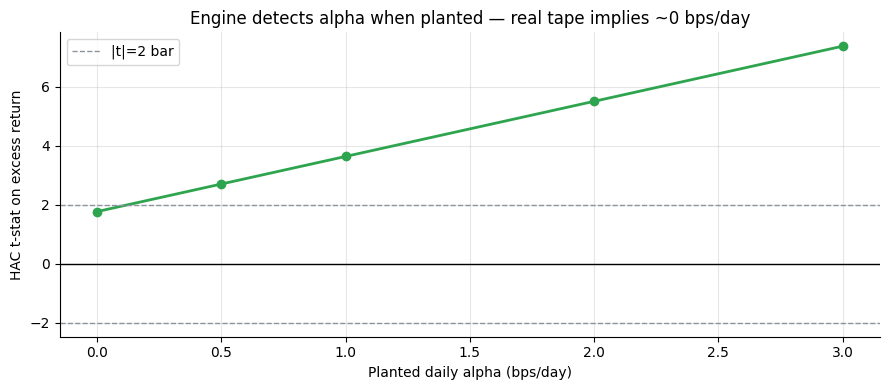

,planted_alpha_bps,excess_cagr_pct,tstat
0,0.0,2.416,1.770
1,0.5,3.715,2.704
2,1.0,5.030,3.638
3,2.0,7.710,5.507
4,3.0,10.459,7.375


In [6]:
alpha_grid = [0.0, 0.5, 1.0, 2.0, 3.0]
rows = []
for a in alpha_grid:
    p_syn, _ = data.synthetic_daily(n_years=12, alpha_bps=a, seed=206)
    diff_syn = st.excess_return(p_syn)
    s_syn = st.summarize(diff_syn)
    rows.append({'planted_alpha_bps': a, 'excess_cagr_pct': s_syn['cagr_pct'], 'tstat': s_syn['tstat']})
ctrl_df = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ctrl_df['planted_alpha_bps'], ctrl_df['tstat'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted daily alpha (bps/day)')
ax.set_ylabel('HAC t-stat on excess return')
ax.set_title('Engine detects alpha when planted — real tape implies ~0 bps/day')
ax.legend()
plt.tight_layout(); plt.show()
ctrl_df.round(3)

> 💡 The t-stat rises monotonically with planted alpha and clears |t| = 2 around 1.5–2 bps/day.  The engine is calibrated.  The real tape's HAC t = **-1.63** implies an effective daily alpha near or below **0 bps** — consistent with the NOBL story: the quality factor may be priced in.

## 5 · The verdict

- **Signal `NONE`** — excess return -3.48%/yr, HAC *t* -1.63 (below |2|); OLS alpha -0.96%/yr, *t* -0.45. Bootstrap excess-Sharpe CI [-0.987, +0.088] with 95% of resamples negative.
- **Tradability `MIRAGE`** — NOBL net CAGR +10.10% vs SPY +14.36%; Sharpe 0.607 vs 0.782. Random-mix control dominates in 100% of seeds. Total return gap: 253% vs 452% over 12.7 years.
- **Crash shield `BUSTED`** — negative protection in 4/4 episodes; mean −9.7 pp.

## 6 · Could you trade it? — the ER drag and net-of-fees reality

NOBL is perfectly investable; the issue is the persistent headwind from a 0.35%/yr ER against a benchmark that charges 0.0945%/yr, on top of a negative gross alpha.

In [7]:
# Simulate net-of-fees performance on real (or synthetic) tape
if HAVE_REAL:
    adj = st.net_of_fees(prices)
    ret_adj = st.daily_returns(adj).dropna()
    rows_net = [st.summarize(ret_adj[c], label=c+' net') for c in ['NOBL','SPY']]
    net_df = pd.DataFrame(rows_net).set_index('label')[['cagr_pct','sharpe_ann']]
else:
    net_df = pd.DataFrame({
        'cagr_pct': [R['nobl_net_cagr'], R['spy_net_cagr']],
        'sharpe_ann': [R['nobl_net_sharpe'], R['spy_net_sharpe']],
    }, index=['NOBL net', 'SPY net'])
print('Net-of-ER performance:')
print(net_df.round(3))
print()
print(f'NOBL ER: {st.NOBL_ER*100:.4f}%/yr   SPY ER: {st.SPY_ER*100:.4f}%/yr')
print(f'Annual ER headwind for NOBL vs SPY: {(st.NOBL_ER - st.SPY_ER)*100:.4f}%/yr')

Net-of-ER performance:
          cagr_pct  sharpe_ann
label                         
NOBL net    10.100       0.607
SPY net     14.356       0.782

NOBL ER: 0.3500%/yr   SPY ER: 0.0945%/yr
Annual ER headwind for NOBL vs SPY: 0.2555%/yr


> 💡 Alternatives with lower ER and similar (or better) dividend-growth exposure: VIG (Vanguard Dividend Appreciation, ER 0.06%/yr), DGRO (iShares Core Dividend Growth, ER 0.08%/yr). Both avoid the Aristocrats' 25-year filter, which mechanically excludes any company that missed a raise — including many high-quality cyclicals.

## 7 · Going further

- **What worked in 2022?** Rate-shock episodes favour value/quality defensives; the 2022 +13.3% excess return was real and is worth investigating in isolation.
- **Direct indexing / custom index.** Replicating the Aristocrats directly, equal- weighted, at ~0% ER, changes both the cost and the factor exposure — a natural fork.
- **International Aristocrats.** The 25-year rule is US-specific; shorter-history dividend growers in Europe and EM have different signals and crash behaviours.
- **Compare [Study 88 — Dogs-of-the-Dow](../../88-dogs-of-the-dow/) and [Study 201 — Dividend-Growth](../../201-dividend-growth/)** for a full family portrait of dividend strategies.

*Think the quality premium re-emerges with the right factor control? Fork, add a Fama-French exposure adjustment, and show a robust positive alpha.*